In [9]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
# from ultralytics import YOLO
import os  
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')  
if gpus:  
    tf.config.experimental.set_memory_growth(gpus[0], True)
from tensorflow import keras
from sklearn.metrics.pairwise import cosine_similarity

### Zadanie 13


image 1/10 /mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/ds-learning/data/img1.jpg: 256x640 11 persons, 6.5ms
image 2/10 /mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/ds-learning/data/img10.webp: 640x640 4 persons, 6.1ms
image 3/10 /mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/ds-learning/data/img2.jpg: 448x640 8 persons, 6.7ms
image 4/10 /mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/ds-learning/data/img3.jpg: 640x512 4 persons, 6.8ms
image 5/10 /mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/ds-learning/data/img4.jpg: 384x640 5 persons, 6.8ms
image 6/10 /mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/ds-learning/data/img5.jpg: 480x640 8 persons, 6.2ms
image 7/10 /mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/ds-learning/data/img6.jpg: 448x640 2 persons, 6.2ms
image 8/10 /mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/ds-learning/data/img7.webp: 448x640 9 persons, 5.9ms
image 9/10 /mnt/Dane_Ubuntu/PythonProjects/#Data Science Course/ds-

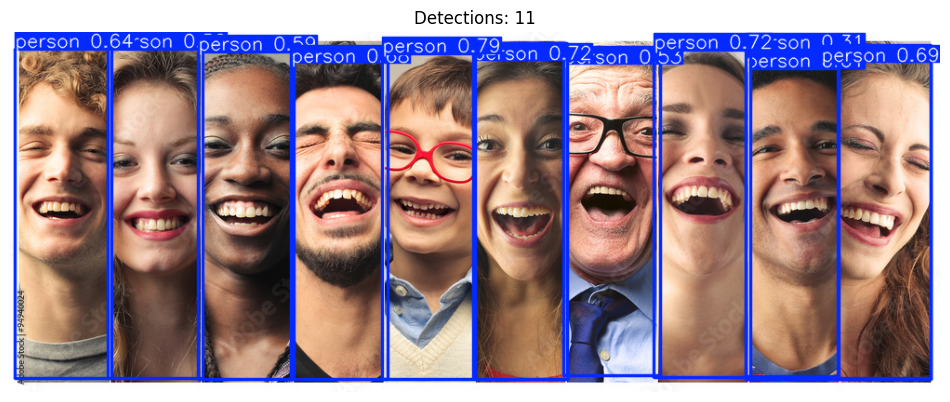

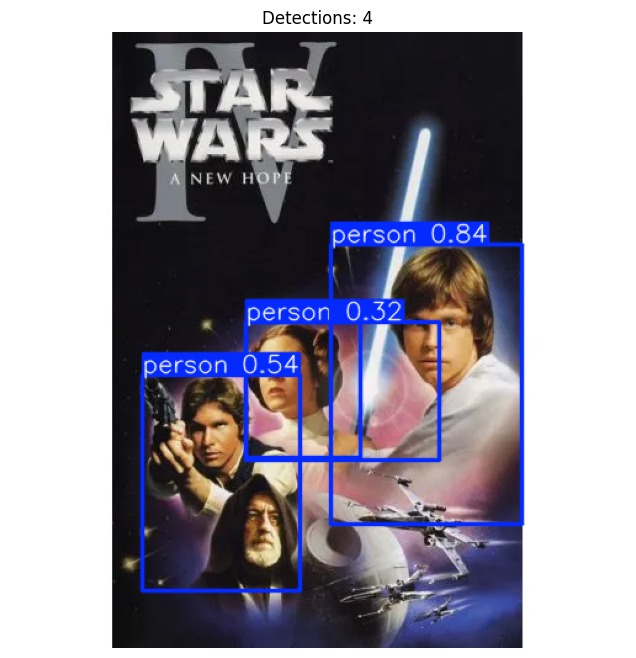

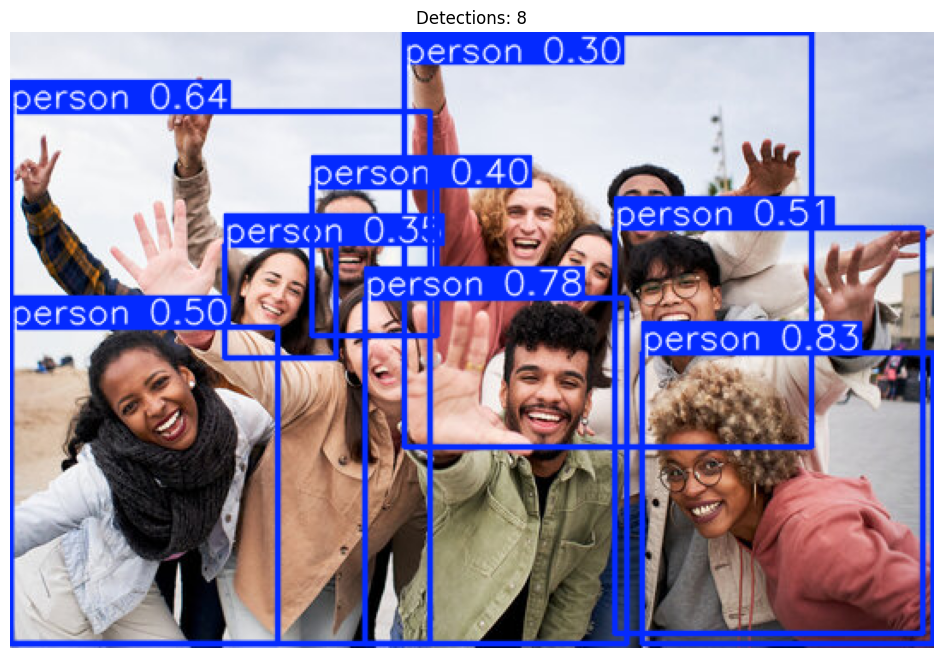

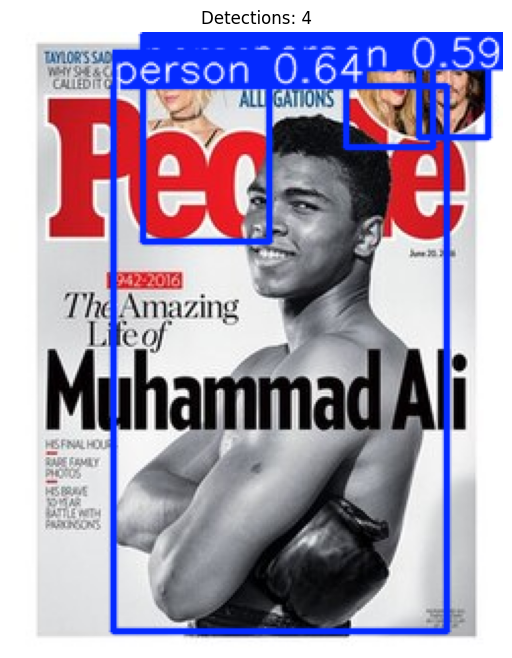

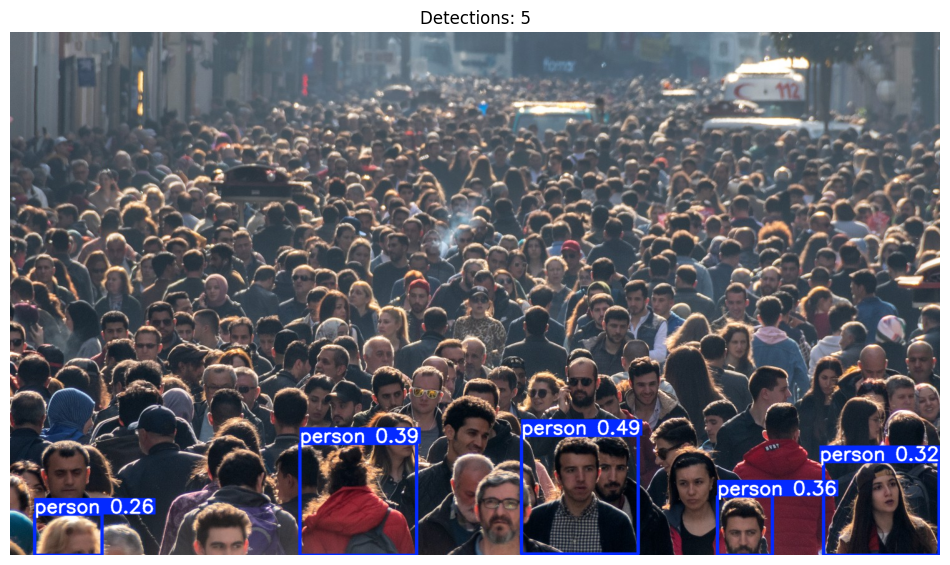

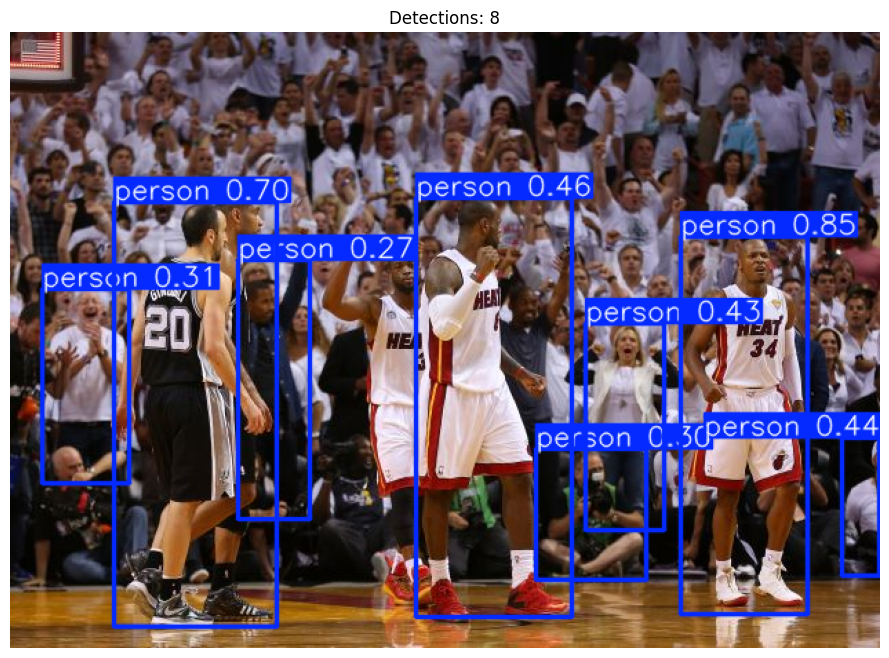

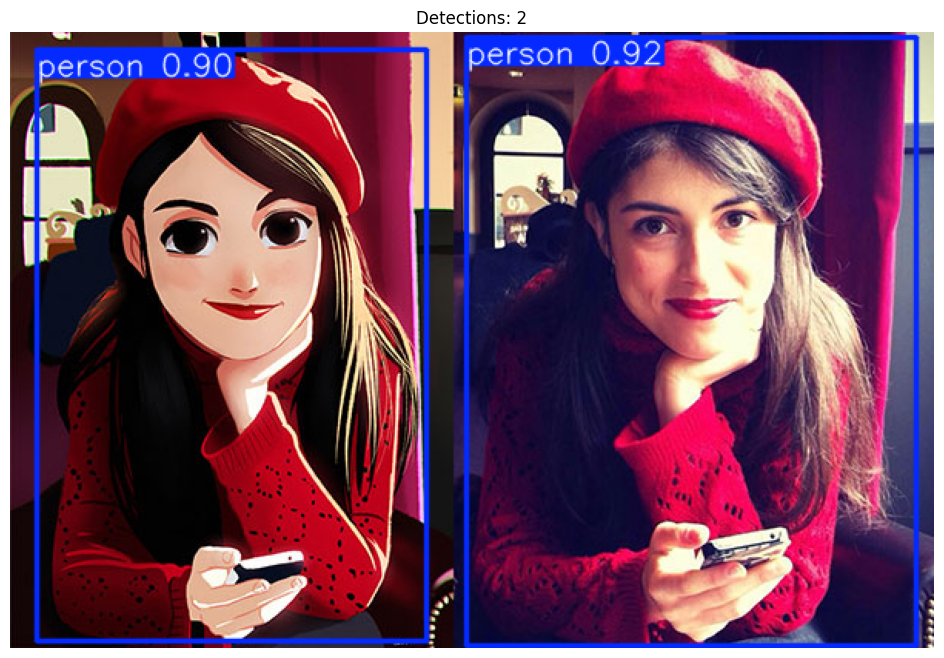

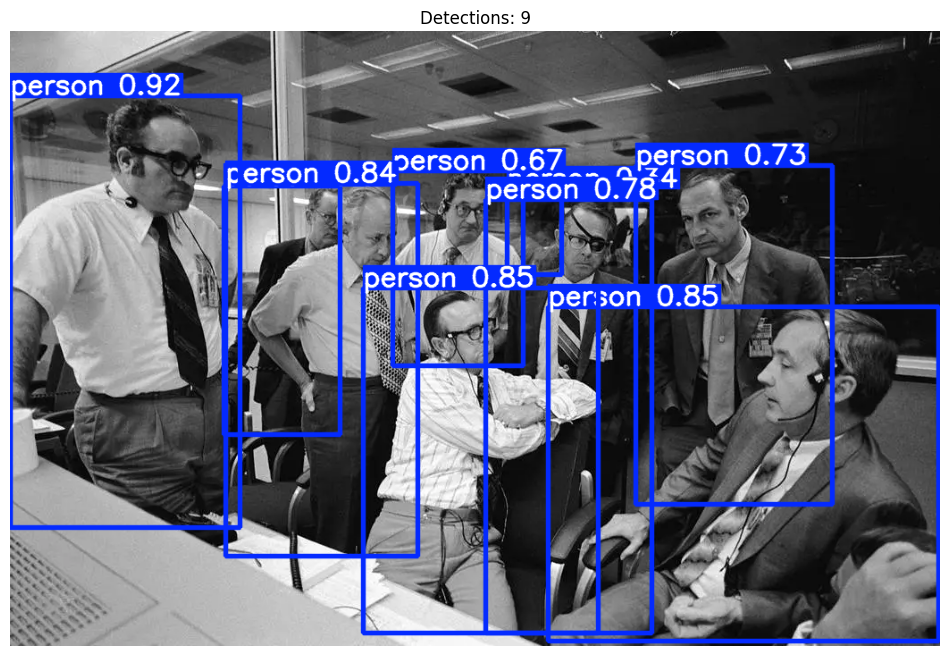

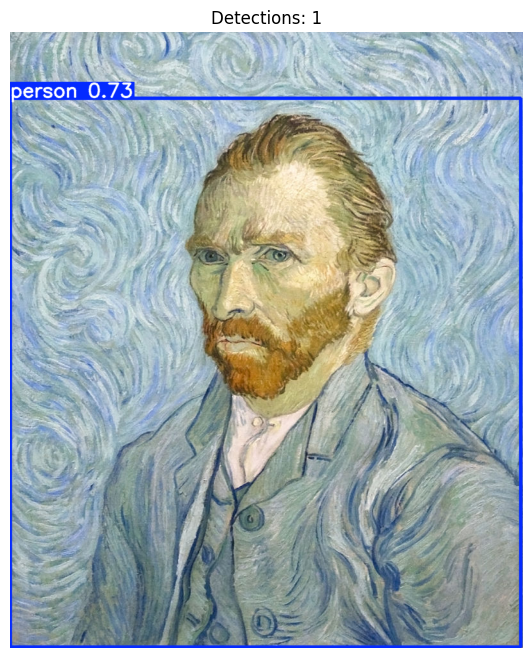

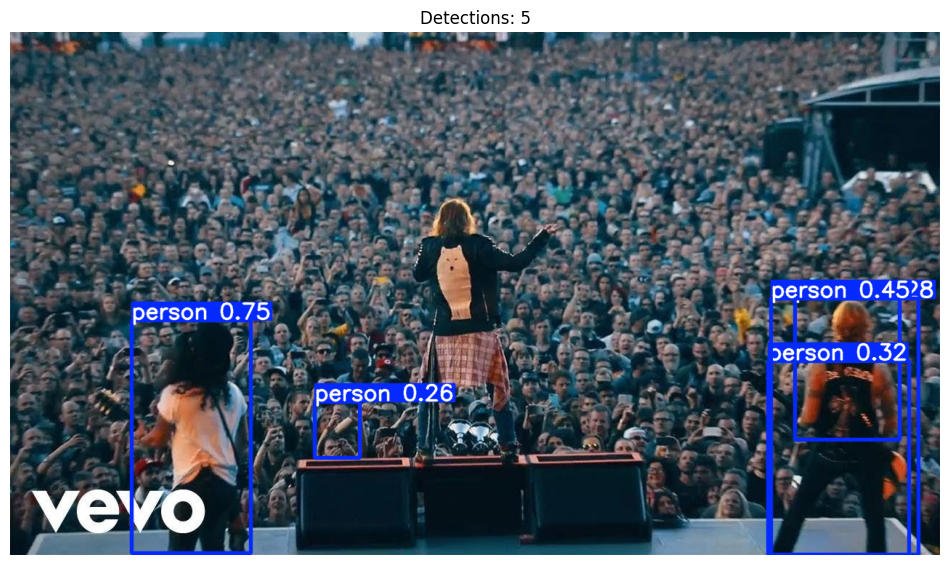

In [11]:
model = YOLO("yolov8n.pt")

results = model.predict(source='./data', classes=0)

for result in results:
    img = result.plot()
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB for matplotlib
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Detections: {len(result.boxes)}")
    plt.show()

### Zadanie
wczytac mnist i jakis pretrain model - policzyc embeddingi dla wszystkich danych i potem dla kazdej klasy losowo wybrac 1 przyklad i vis top 3 najbardziej podobnych obrazow

In [5]:
mnist = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test])
X_res = np.array([cv2.resize(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB), (96, 96)) for img in X])
X_res = X_res / 255.0

embeddings = X.reshape(len(X), -1) / 255.0
embeddings.shape

(70000, 784)

In [15]:
rand_classes = []
for cls in range(len(np.unique(y))):
    idx = np.where(y == cls)[0]
    rand_classes.append(np.random.choice(idx))

results = {}
for i in rand_classes:
    emb = embeddings[i].reshape(1, -1)
    sim = cosine_similarity(emb, embeddings)[0]
    sim[i] = -1
    top_3 = np.argsort(sim)[-3:][::-1]
    results[i] = top_3
results

{np.int64(13211): array([ 2557, 15965, 46980]),
 np.int64(38779): array([43633, 35389, 65291]),
 np.int64(37501): array([11013, 11230,  2065]),
 np.int64(15053): array([43204, 59100,  1581]),
 np.int64(3573): array([27552, 53451,  3611]),
 np.int64(68082): array([29487, 14199, 67324]),
 np.int64(52674): array([27320, 58665, 12834]),
 np.int64(3790): array([45361,  2344, 57839]),
 np.int64(25796): array([68735, 36635, 50268]),
 np.int64(17550): array([ 7680, 39621, 42289])}

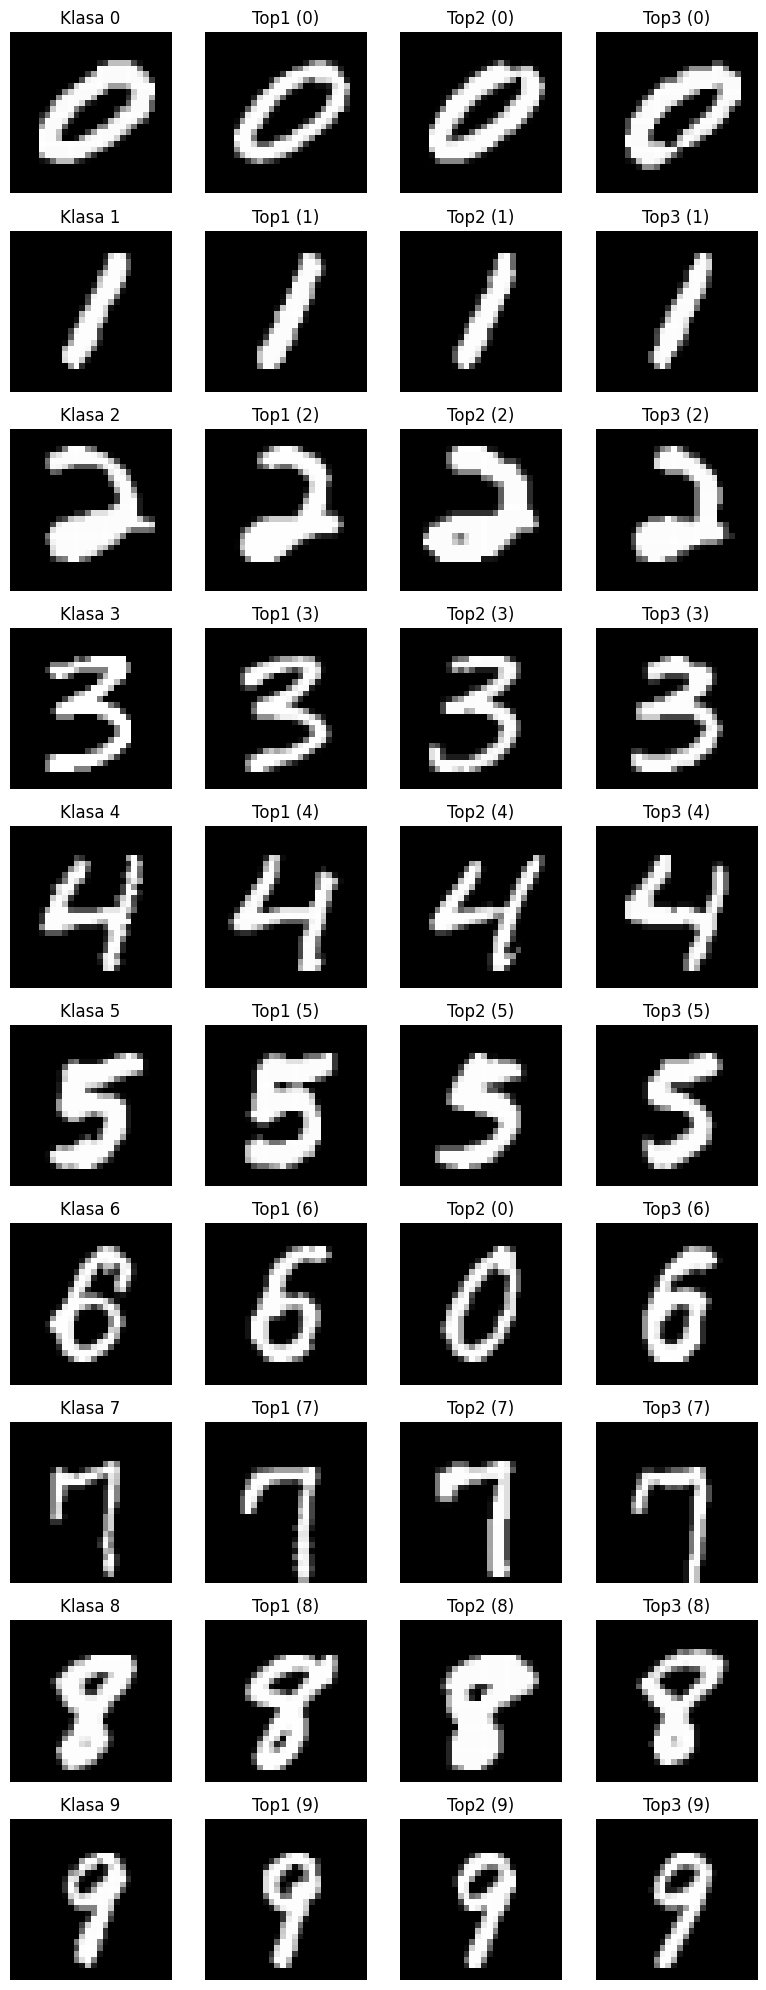

In [16]:
ig, axes = plt.subplots(10, 4, figsize=(8, 20))
for row, query_idx in enumerate(rand_classes):
    top3_idx = results[query_idx]
    for col, idx in enumerate([query_idx] + list(top3_idx)):
        axes[row, col].imshow(X[idx], cmap='gray')
        axes[row, col].set_title(f"Klasa {y[idx]}" if col == 0 else f"Top{col} ({y[idx]})")
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()